# Разведочный анализ данных. Исследование и визуализация данных.

## 1) Текстовое описание набора данных

В качестве набора данных мы будем использовать набор данных 
по каждой карты в Clash Royale - https://www.kaggle.com/datasets/hrish4/clash-royale-cards-data/data

Набор данных "Clash Royale Cards" предоставляет детальную информацию о всех картах в популярной мобильной игре Clash Royale. Этот датасет объединяет статические атрибуты карт с динамическими метриками производительности из актуальных игровых данных.
Игра Clash Royale, разработанная Supercell, представляет собой комбинацию коллекционной карточной игры и tower defense, где игроки используют карты с различными юнитами, заклинаниями и защитными сооружениями для уничтожения башен противника. 
Понимание характеристик и баланса карт имеет решающее значение для разработки успешных игровых стратегий.

Датасет состоит из файла:
- clash_royale_cards.csv

Файл содержит следующие колонки:
- Card - название карты
- ID - уникальный идентификатор карты
- MaxLevel - максимальный уровень карты
- ElixirCost - стоимость карты в единицах эликсира (от 1 до 7)
- Rarity - редкость карты (Common, Rare, Epic, Legendary)
- WinRate - процент побед при использовании карты
- WinRateChange - Изменение процента побед по сравнению с предыдущим сезоном (%)
- Usage - частота использования карты
- UsageChange - Изменение коэффициента использования по сравнению с предыдущим сезоном (%)



# Импорт библиотек
Импортируем библиотеки с помощью команды import. Как правило, все команды import размещают в первой ячейке ноутбука, но мы в этом примере будем подключать все библиотеки последовательно, по мере их использования.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

# Загрузка данных

Загрузим файлы датасета в помощью библиотеки Pandas. 

Они представляют собой данные в формате CSV (https://ru.wikipedia.org/wiki/CSV). Часто в файлах такого формата в качестве разделителей используются символы ",", ";" или табуляция. Поэтому вызывая метод read_csv всегда стоит явно указывать разделитель данных с помощью параметра sep. Чтобы узнать какой разделитель используется в файле его рекомендуется предварительно посмотреть в любом текстовом редакторе.

In [2]:
# Будем анализировать данные только на обучающей выборке
data = pd.read_csv('clash_royale_cards.csv', sep=",")

# 2) Основные характеристики датасета

In [3]:
# Первые 5 строк датасета
data.head()

,Card,id,maxLevel,elixirCost,rarity,Win Rate,Win Rate Change,Usage,Usage Change
0,Knight,26000000,14,3.0,common,51.79,1.59,8.88,-0.24
1,Archers,26000001,14,3.0,common,46.10,0.66,1.44,0.00
2,Goblins,26000002,14,2.0,common,54.32,1.04,3.60,0.00
3,Giant,26000003,12,5.0,rare,59.10,1.10,2.32,-0.08
4,P.E.K.K.A,26000004,9,7.0,epic,50.61,1.65,3.28,-0.16


In [4]:
# Размер датасета - 8143 строк, 7 колонок
data.shape

(119, 9)

In [5]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 119


In [6]:
# Список колонок
data.columns

Index(['Card', 'id', 'maxLevel', 'elixirCost', 'rarity', 'Win Rate',
       'Win Rate Change', 'Usage', 'Usage Change'],
      dtype='object')

In [7]:
# Список колонок с типами данных
data.dtypes

Card                object
id                   int64
maxLevel             int64
elixirCost         float64
rarity              object
Win Rate           float64
Win Rate Change    float64
Usage              float64
Usage Change       float64
dtype: object

In [8]:
# Проверим наличие пустых значений
# Цикл по колонкам датасета
for col in data.columns:
    # Количество пустых значений - все значения заполнены
    temp_null_count = data[data[col].isnull()].shape[0]
    print('{} - {}'.format(col, temp_null_count))

Card - 0
id - 0
maxLevel - 0
elixirCost - 1
rarity - 0
Win Rate - 0
Win Rate Change - 0
Usage - 0
Usage Change - 0


In [9]:
# Основные статистические характеристки набора данных
data.describe()

,id,maxLevel,elixirCost,Win Rate,Win Rate Change,Usage,Usage Change
count,1.190000e+02,119.000000,118.000000,119.000000,119.000000,119.000000,119.000000
mean,2.646222e+07,10.134454,3.974576,53.292605,0.422353,5.337143,-0.020840
std,7.788360e+05,3.217864,1.544009,3.805675,1.654431,6.127417,0.298872
min,2.600000e+07,4.000000,1.000000,43.880000,-6.880000,0.160000,-1.040000
25%,2.600003e+07,9.000000,3.000000,50.975000,-0.380000,1.760000,-0.160000
50%,2.600006e+07,9.000000,4.000000,53.230000,0.380000,3.280000,0.000000
75%,2.700000e+07,12.000000,5.000000,56.205000,1.305000,7.280000,0.160000
max,2.800002e+07,14.000000,9.000000,61.780000,6.920000,42.880000,1.120000


In [13]:
# Определим уникальные значения для целевого признака
data['maxLevel'].unique()

array([14, 12,  9,  6,  4])

Целевой признак имеет значения 4, 6, 9, 12, 14.

# 3) Визуальное исследование датасета
Для визуального исследования могут быть использованы различные виды диаграмм, мы построим только некоторые варианты диаграмм, которые используются достаточно часто.

### [Диаграмма рассеяния](https://en.wikipedia.org/wiki/Scatter_plot)

Позволяет построить распределение двух колонок данных и визуально обнаружить наличие зависимости. Не предполагается, что значения упорядочены (например, по времени).

<Axes: xlabel='Usage', ylabel='Win Rate'>

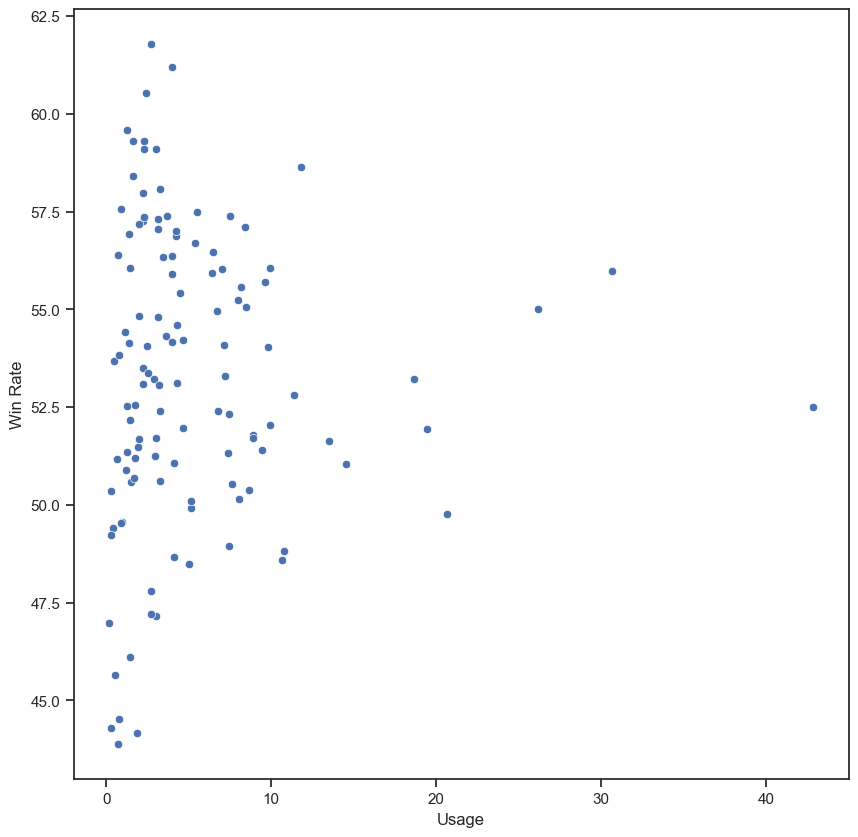

In [18]:
fig, ax = plt.subplots(figsize=(10,10)) 
sns.scatterplot(ax=ax, x='Usage', y='Win Rate', data=data)

Можно видеть что между полями Win Rate и Usage не присутствует зависимость.

Посмотрим насколько на эту зависимость влияет целевой признак.

<Axes: xlabel='Usage', ylabel='Win Rate'>

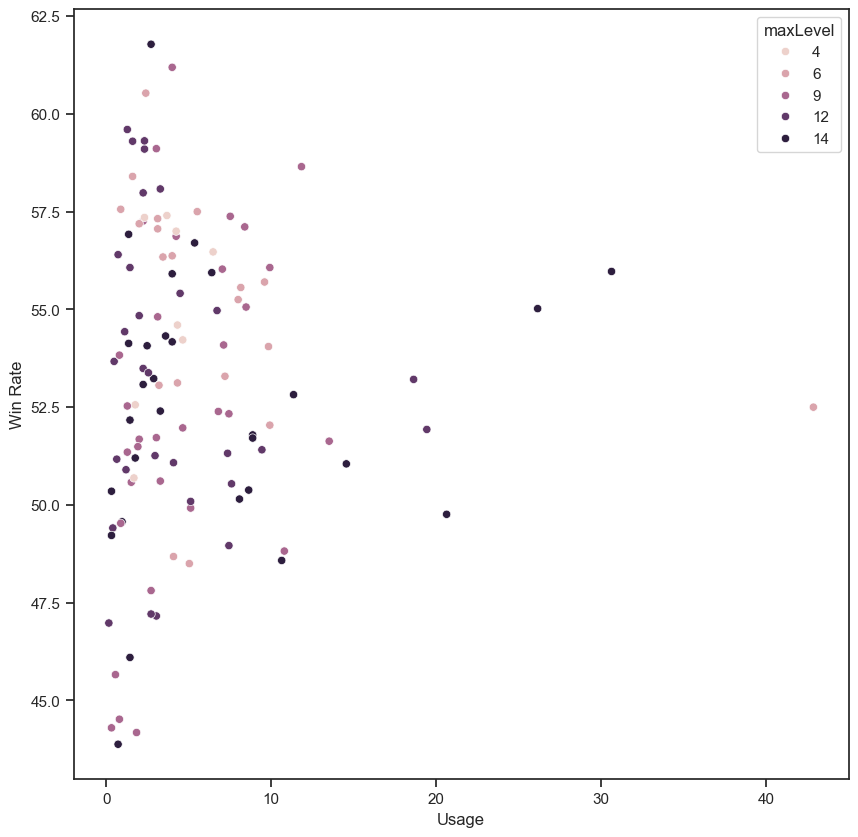

In [20]:
fig, ax = plt.subplots(figsize=(10,10)) 
sns.scatterplot(ax=ax, x='Usage', y='Win Rate', data=data, hue='maxLevel')

## [Гистограмма](https://en.wikipedia.org/wiki/Histogram) 
Позволяет оценить плотность вероятности распределения данных.

C:\Users\Bizar\AppData\Local\Temp\ipykernel_8400\1830533174.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['elixirCost'])


<Axes: xlabel='elixirCost', ylabel='Density'>

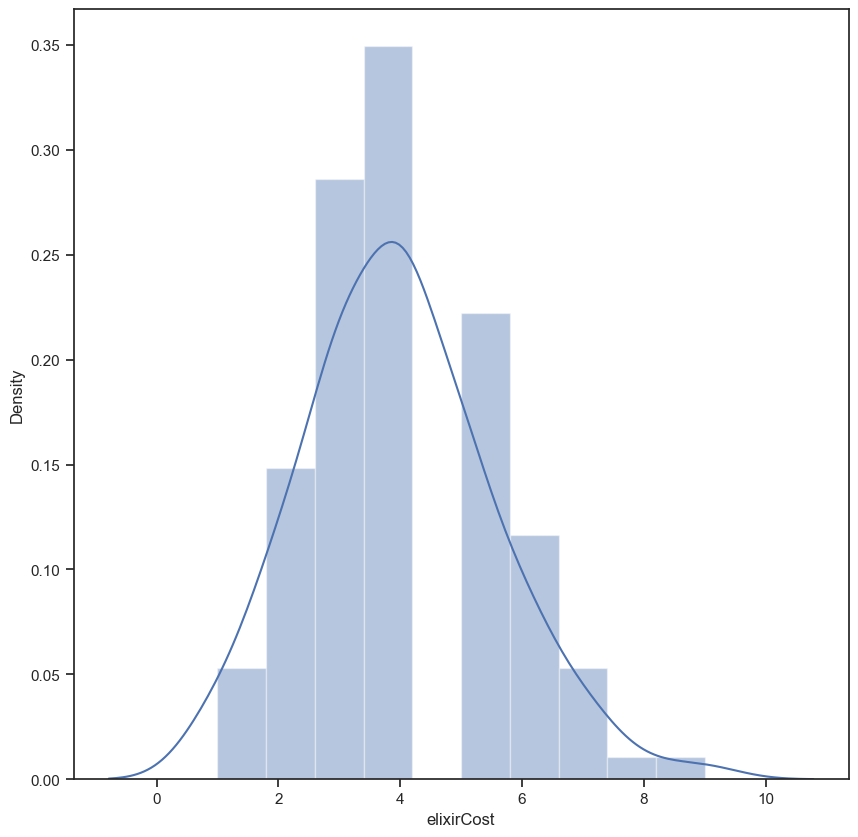

In [22]:
fig, ax = plt.subplots(figsize=(10,10)) 
sns.distplot(data['elixirCost'])

### Jointplot
Комбинация гистограмм и диаграмм рассеивания.

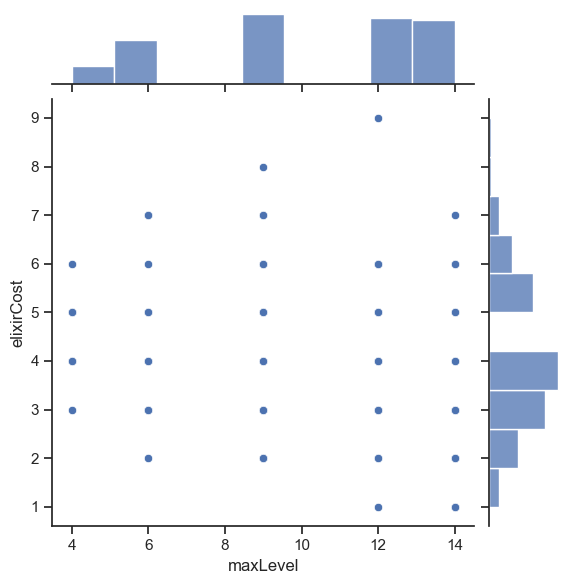

In [26]:
sns.jointplot(x='maxLevel', y='elixirCost', data=data)

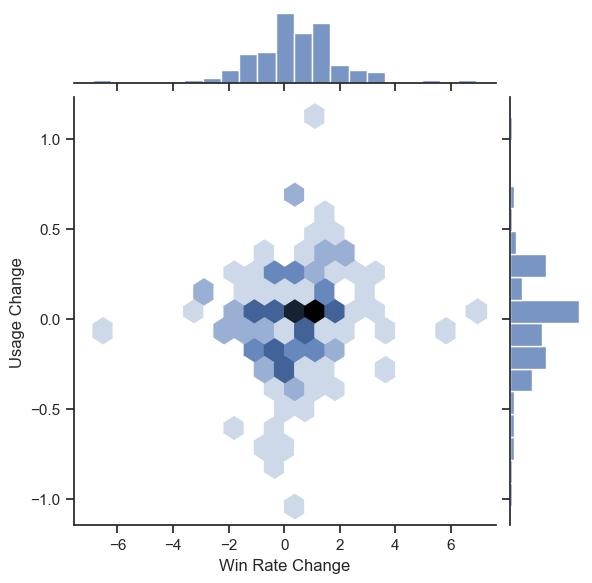

In [28]:
sns.jointplot(x='Win Rate Change', y='Usage Change', data=data, kind="hex")

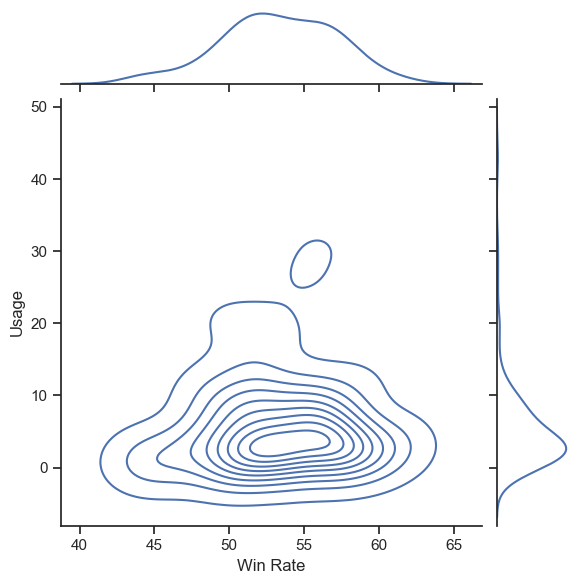

In [30]:
sns.jointplot(x='Win Rate', y='Usage', data=data, kind="kde")

### "Парные диаграммы"
Комбинация гистограмм и диаграмм рассеивания для всего набора данных.

Выводится матрица графиков. На пересечении строки и столбца, которые соответстуют двум показателям, строится диаграмма рассеивания. В главной диагонали матрицы строятся гистограммы распределения соответствующих показателей.

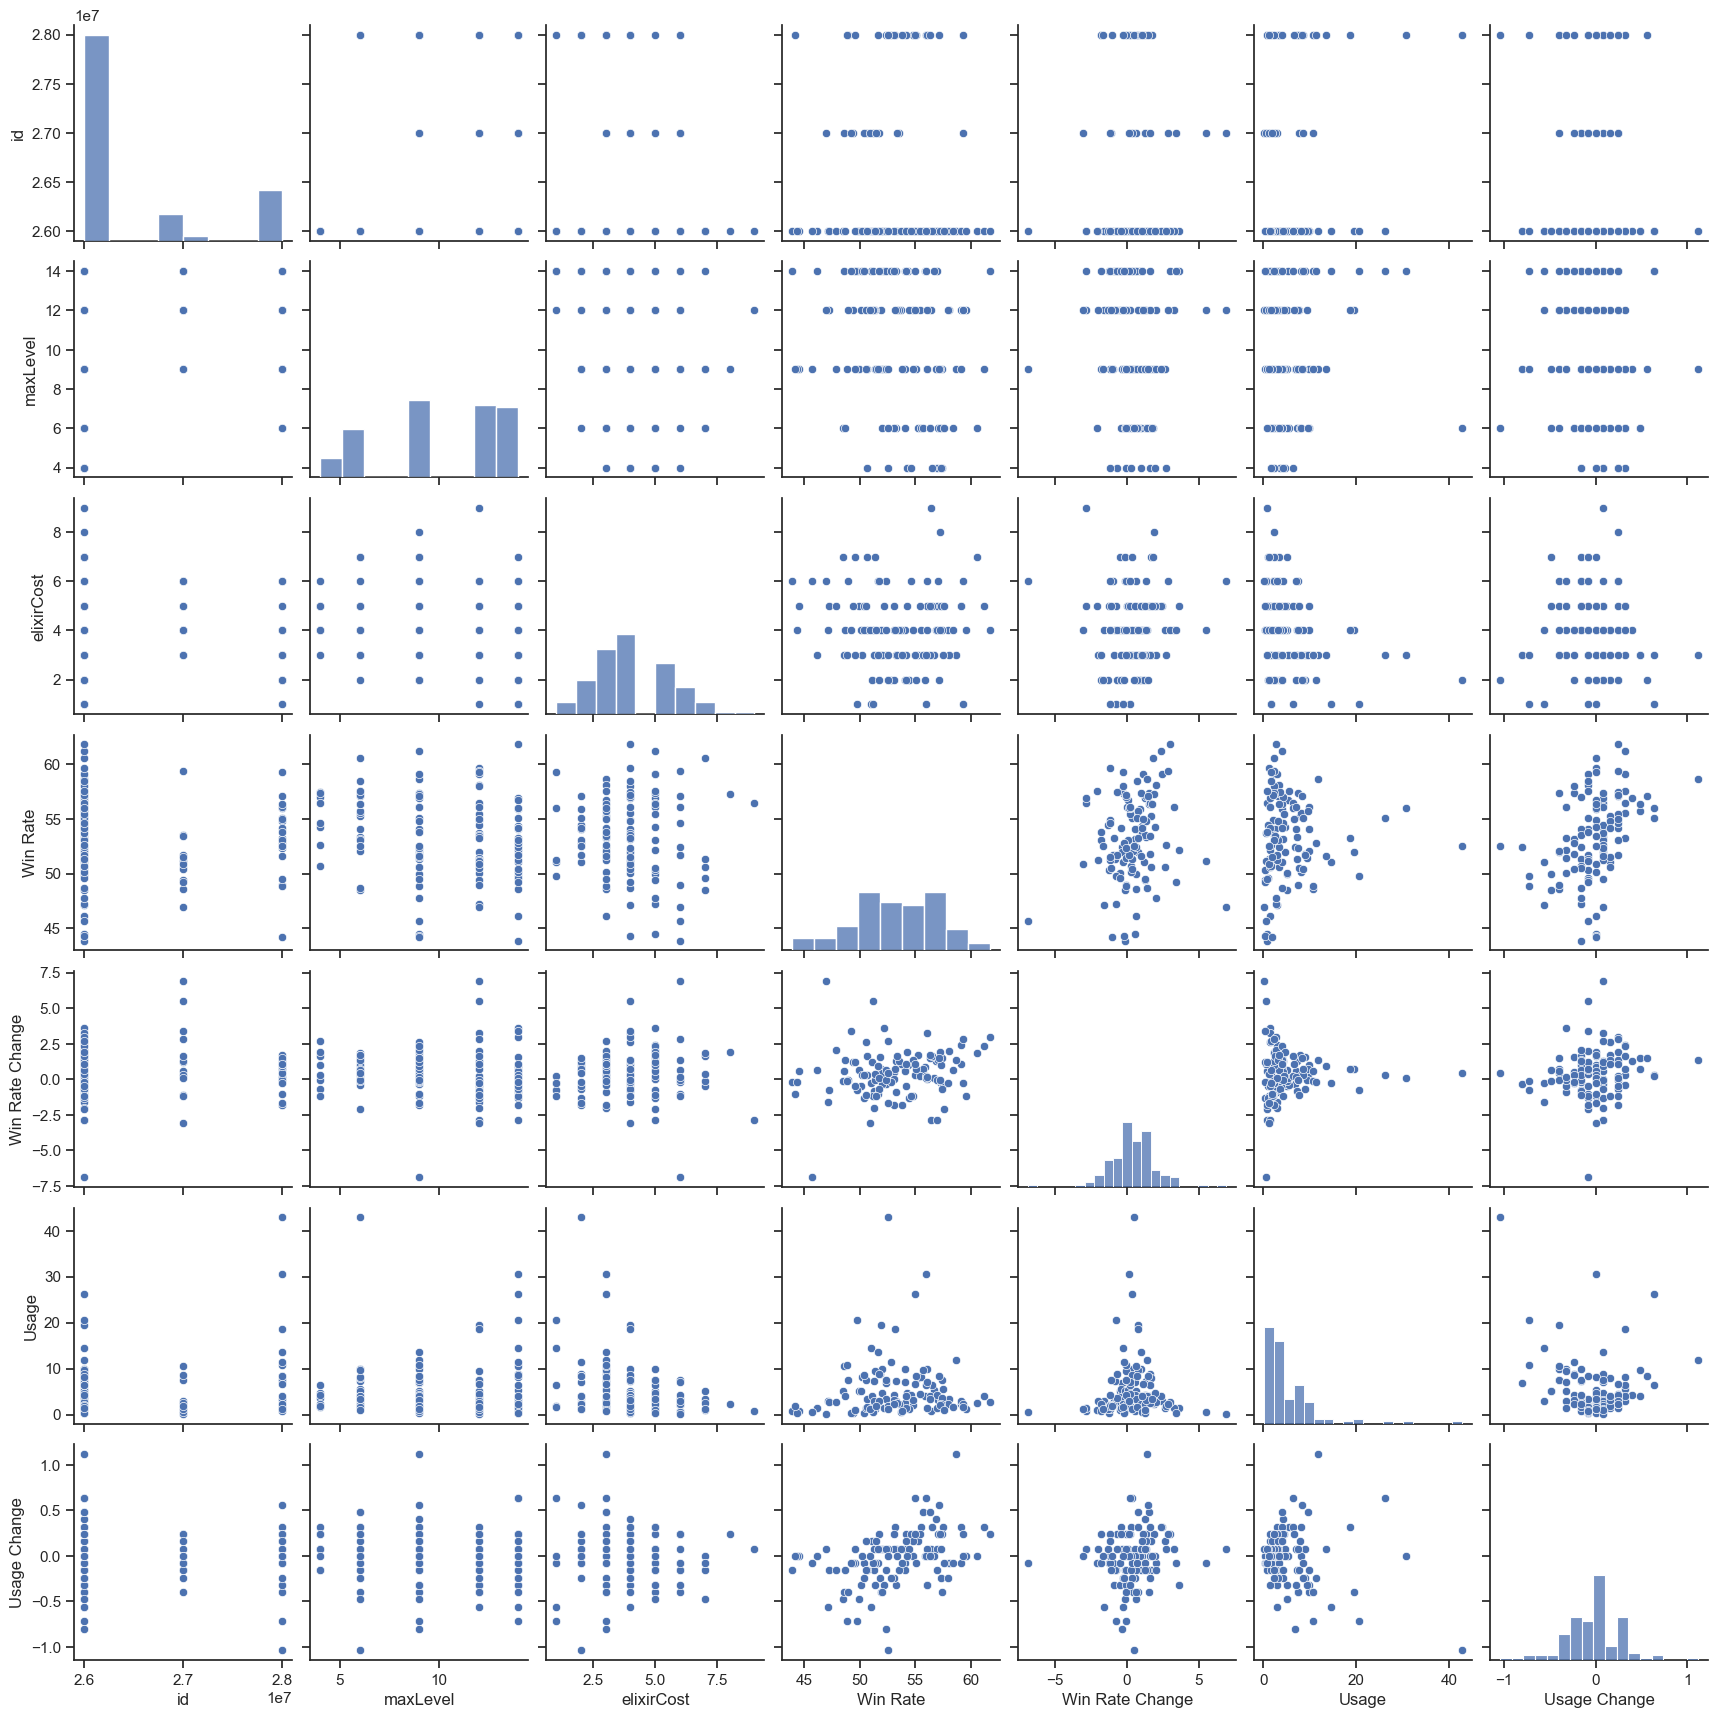

In [31]:
sns.pairplot(data)

С помощью параметра "hue" возможна группировка по значениям какого-либо признака.

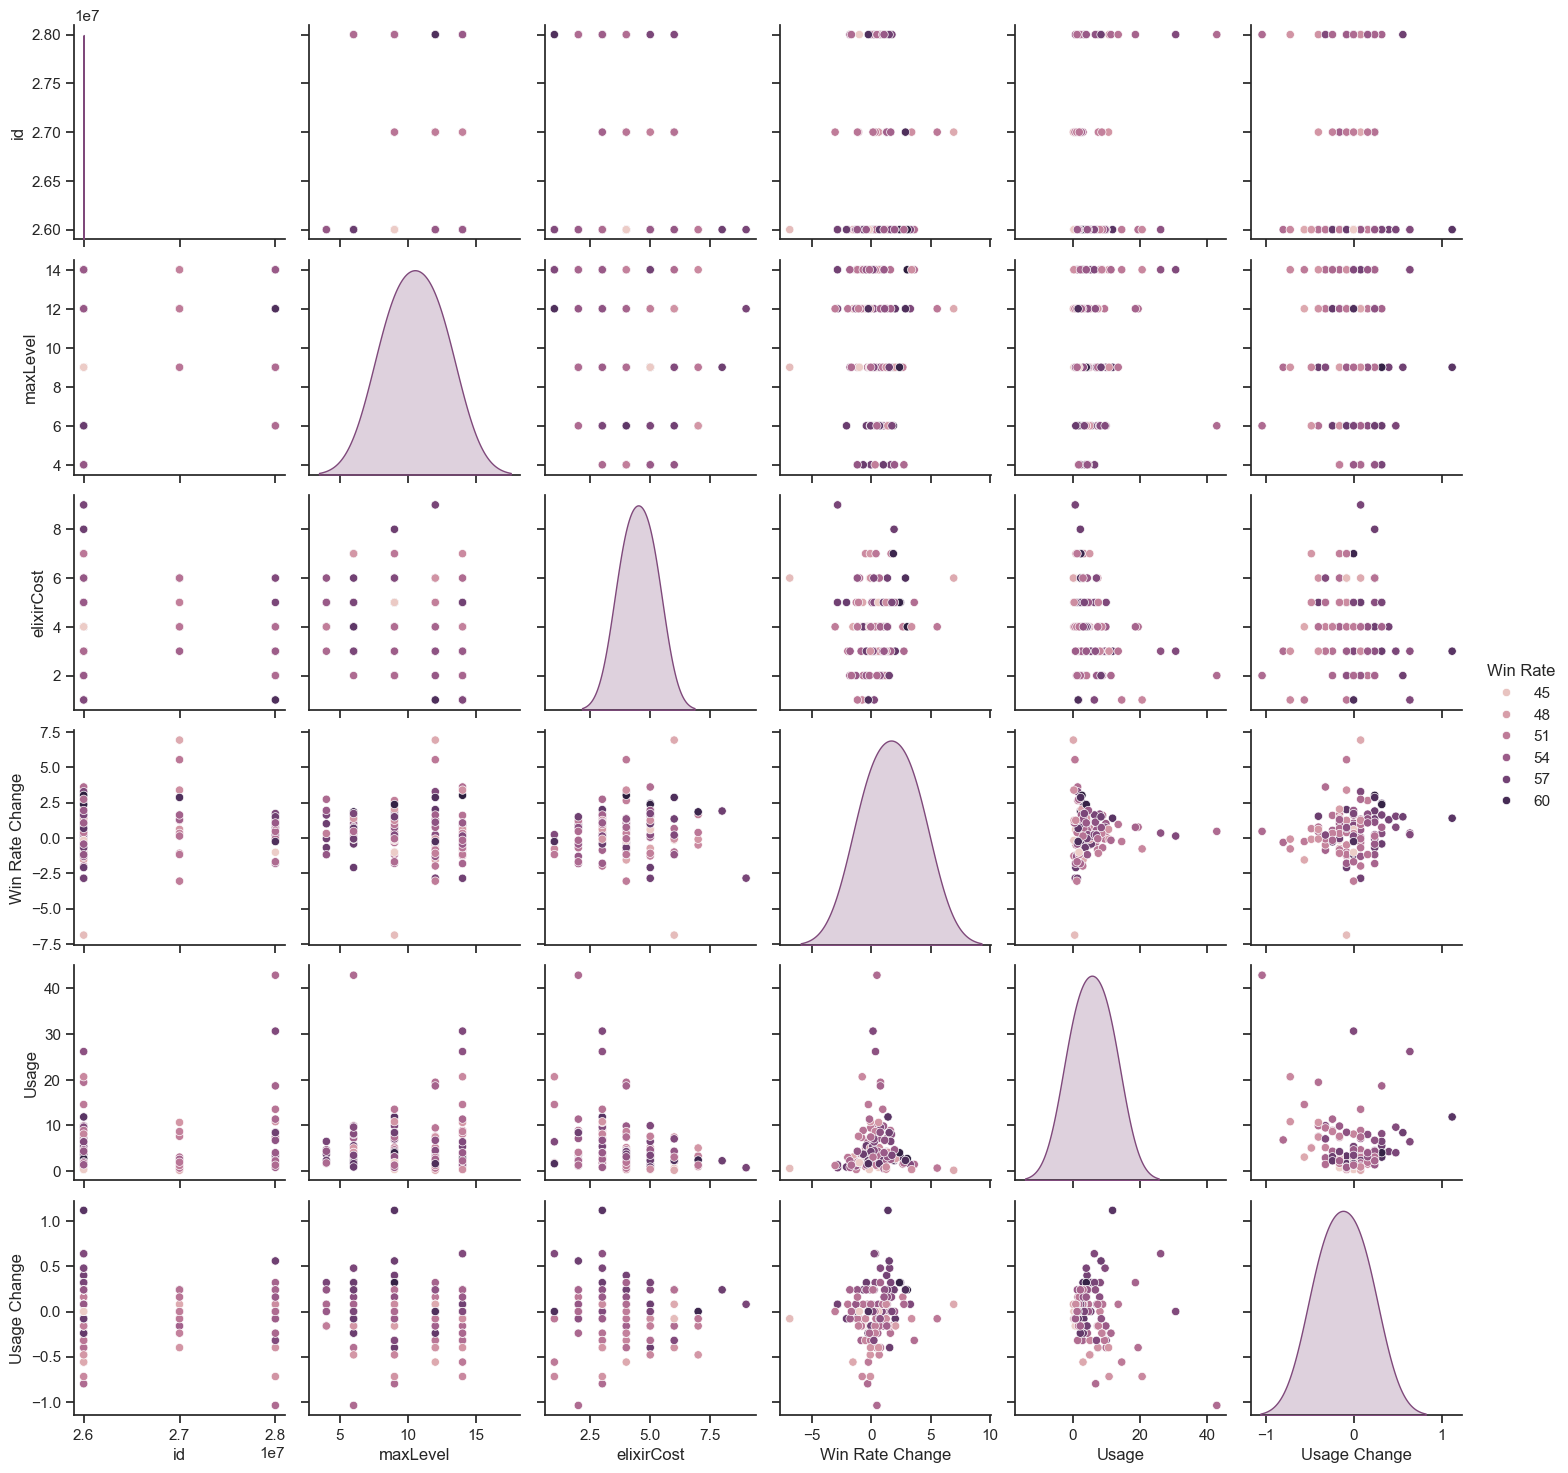

In [33]:
sns.pairplot(data, hue="Win Rate")

### [Ящик с усами](https://en.wikipedia.org/wiki/Box_plot)
Отображает одномерное распределение вероятности.

<Axes: xlabel='Usage'>

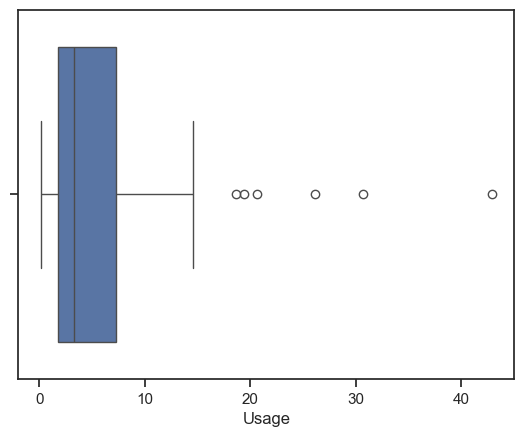

In [37]:
sns.boxplot(x=data['Usage'])

<Axes: ylabel='Usage'>

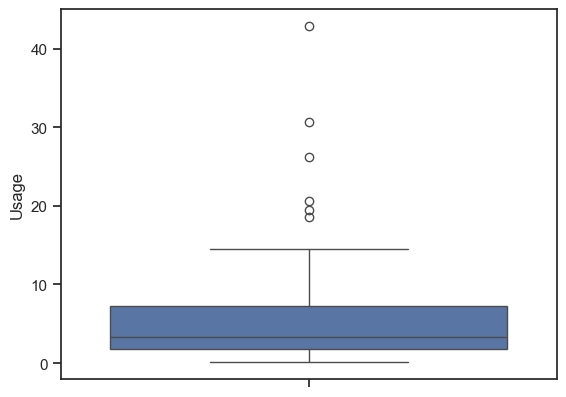

In [39]:
# По вертикали
sns.boxplot(y=data['Usage'])

<Axes: xlabel='Win Rate', ylabel='Usage'>

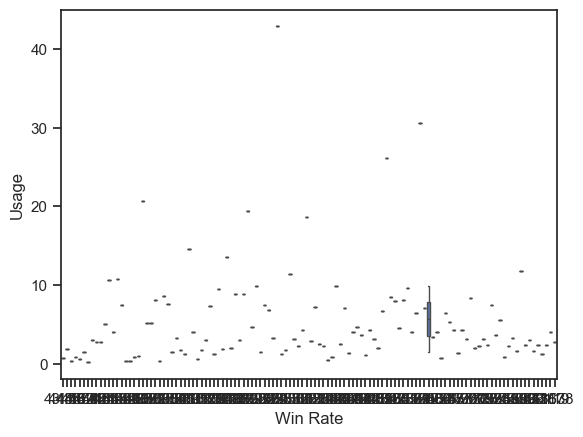

In [41]:
# Распределение параметра Humidity сгруппированные по Occupancy.
sns.boxplot(x='Win Rate', y='Usage', data=data)

### [Violin plot](https://en.wikipedia.org/wiki/Violin_plot)
Похоже на предыдущую диаграмму, но по краям отображаются распределения плотности - https://en.wikipedia.org/wiki/Kernel_density_estimation

<Axes: xlabel='Usage'>

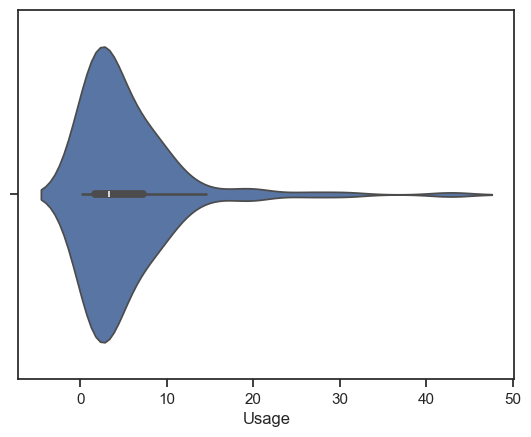

In [43]:
sns.violinplot(x=data['Usage'])

C:\Users\Bizar\AppData\Local\Temp\ipykernel_8400\1024355173.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Usage'], ax=ax[1])


<Axes: xlabel='Usage', ylabel='Density'>

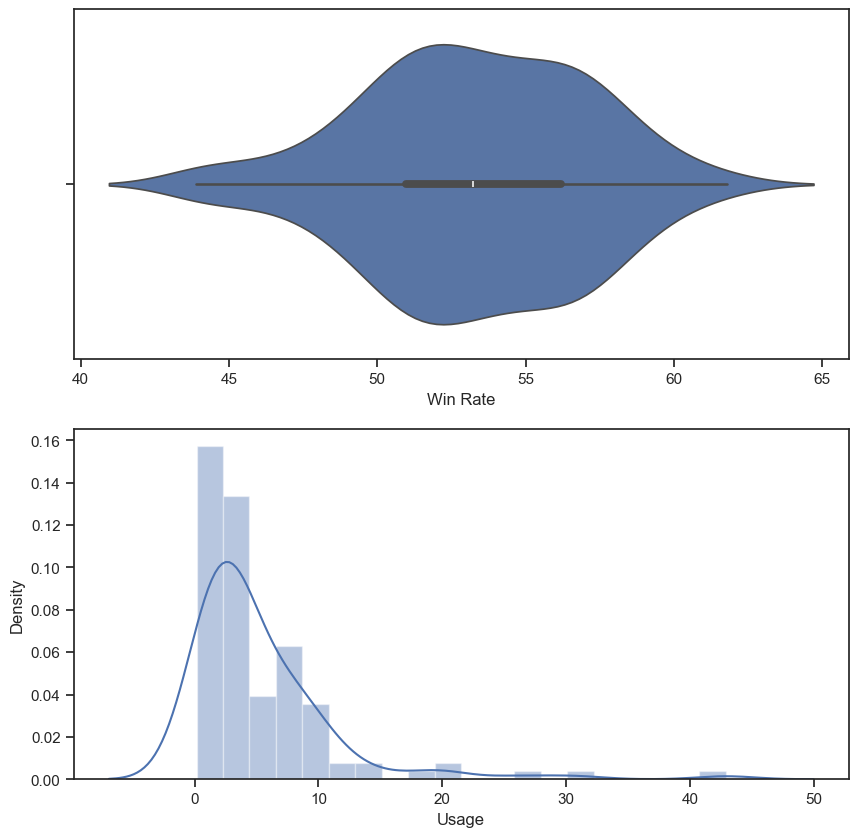

In [51]:
fig, ax = plt.subplots(2, 1, figsize=(10,10))
sns.violinplot(ax=ax[0], x=data['Win Rate'])
sns.distplot(data['Usage'], ax=ax[1])

Из приведенных графиков видно, что violinplot действительно показывает распределение плотности.

<Axes: xlabel='Win Rate', ylabel='Usage'>

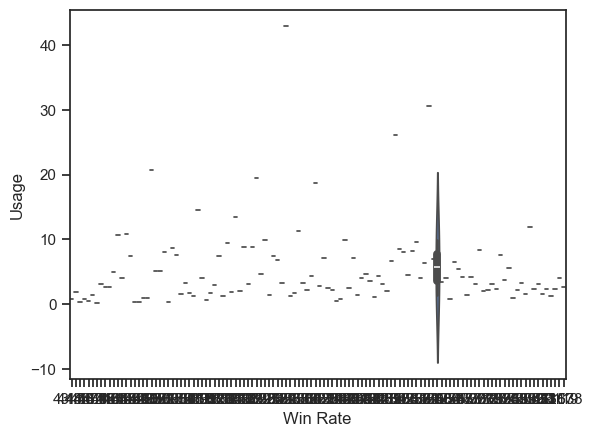

In [56]:
# Распределение параметра Humidity сгруппированные по Occupancy.
sns.violinplot(x='Win Rate', y='Usage', data=data)

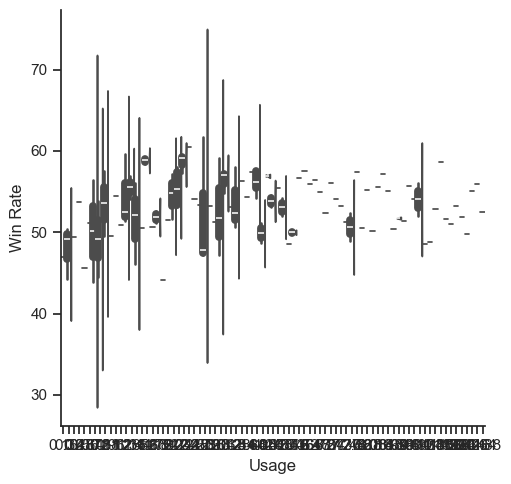

In [62]:
sns.catplot(y='Win Rate', x='Usage', data=data, kind="violin", split=True)

# 4) Информация о корреляции признаков

Проверка корреляции признаков позволяет решить две задачи:
1. Понять какие признаки (колонки датасета) наиболее сильно коррелируют с целевым признаком (в нашем примере это колонка "Occupancy"). Именно эти признаки будут наиболее информативными для моделей машинного обучения. Признаки, которые слабо коррелируют с целевым признаком, можно попробовать исключить из построения модели, иногда это повышает качество модели. Нужно отметить, что некоторые алгоритмы машинного обучения автоматически определяют ценность того или иного признака для построения модели.
1. Понять какие нецелевые признаки линейно зависимы между собой. Линейно зависимые признаки, как правило, очень плохо влияют на качество моделей. Поэтому если несколько признаков линейно зависимы, то для построения модели из них выбирают какой-то один признак.

In [68]:
data.corr(numeric_only=True)

,id,maxLevel,elixirCost,Win Rate,Win Rate Change,Usage,Usage Change,rarity_encoded
id,1.000000,0.096714,-0.191851,-0.086235,0.024400,0.236629,-0.045636,0.075516
maxLevel,0.096714,1.000000,-0.237488,-0.199427,-0.066090,0.029934,-0.094344,0.031684
elixirCost,-0.191851,-0.237488,1.000000,-0.036092,0.043098,-0.317868,-0.014442,0.125291
Win Rate,-0.086235,-0.199427,-0.036092,1.000000,0.161645,0.033095,0.402896,0.051058
Win Rate Change,0.024400,-0.066090,0.043098,0.161645,1.000000,0.000968,0.149551,0.024972
Usage,0.236629,0.029934,-0.317868,0.033095,0.000968,1.000000,-0.219218,-0.056311
Usage Change,-0.045636,-0.094344,-0.014442,0.402896,0.149551,-0.219218,1.000000,-0.058674
rarity_encoded,0.075516,0.031684,0.125291,0.051058,0.024972,-0.056311,-0.058674,1.000000


Корреляционная матрица содержит коэффициенты корреляции между всеми парами признаков.

Корреляционная матрица симметрична относительно главной диагонали. На главной диагонали расположены единицы (корреляция признака самого с собой).


На основе корреляционной матрицы можно сделать следующие выводы:
- Целевой признак наиболее сильно коррелирует с освещенностью (0.9) и концентрацией углекислого газа (0.71). Эти признаки обязательно следует оставить в модели.
- Целевой признак отчасти коррелирует с температурой (0.54). Этот признак стоит также оставить в модели.
- Целевой признак слабо коррелирует с влажностью (0.13) и HumidityRatio (0.3). Скорее всего эти признаки стоит исключить из модели, возможно они только ухудшат качество модели.
- Влажность и HumidityRatio очень сильно коррелируют между собой (0.96). Это неудивительно, ведь HumidityRatio величина производная от влажности. Поэтому из этих признаков в модели можно оставлять только один. 
- Также можно сделать вывод, что выбирая из признаков влажность и HumidityRatio лучше выбрать HumidityRatio, потому что он сильнее коррелирован с целевым признаком. Если линейно зависимые признаки сильно коррелированы с целевым, то оставляют именно тот признак, который коррелирован с целевым сильнее. Но для этой пары признаков этот вывод нельзя считать надежным, потому что и 0.13 и 0.3 являются довольно малыми величинами. 

Описание метода corr - https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html

По умолчанию при построении матрицы используется коэффициент корреляции [Пирсона](https://ru.wikipedia.org/wiki/%D0%9A%D0%BE%D1%80%D1%80%D0%B5%D0%BB%D1%8F%D1%86%D0%B8%D1%8F). Возможно также построить корреляционную матрицу на основе коэффициентов корреляции Кендалла и Спирмена. На практике три метода редко дают значимые различия.

In [69]:
data.corr(method='pearson',numeric_only=True)

,id,maxLevel,elixirCost,Win Rate,Win Rate Change,Usage,Usage Change,rarity_encoded
id,1.000000,0.096714,-0.191851,-0.086235,0.024400,0.236629,-0.045636,0.075516
maxLevel,0.096714,1.000000,-0.237488,-0.199427,-0.066090,0.029934,-0.094344,0.031684
elixirCost,-0.191851,-0.237488,1.000000,-0.036092,0.043098,-0.317868,-0.014442,0.125291
Win Rate,-0.086235,-0.199427,-0.036092,1.000000,0.161645,0.033095,0.402896,0.051058
Win Rate Change,0.024400,-0.066090,0.043098,0.161645,1.000000,0.000968,0.149551,0.024972
Usage,0.236629,0.029934,-0.317868,0.033095,0.000968,1.000000,-0.219218,-0.056311
Usage Change,-0.045636,-0.094344,-0.014442,0.402896,0.149551,-0.219218,1.000000,-0.058674
rarity_encoded,0.075516,0.031684,0.125291,0.051058,0.024972,-0.056311,-0.058674,1.000000


In [70]:
data.corr(method='kendall',numeric_only=True)

,id,maxLevel,elixirCost,Win Rate,Win Rate Change,Usage,Usage Change,rarity_encoded
id,1.000000,-0.088460,-0.097052,0.004843,-0.008982,-0.069770,0.155832,0.032285
maxLevel,-0.088460,1.000000,-0.220252,-0.163856,-0.108100,-0.050555,-0.110700,-0.104281
elixirCost,-0.097052,-0.220252,1.000000,-0.022583,0.071821,-0.237459,-0.051115,0.108856
Win Rate,0.004843,-0.163856,-0.022583,1.000000,0.142012,0.059623,0.316757,0.036323
Win Rate Change,-0.008982,-0.108100,0.071821,0.142012,1.000000,0.048802,0.140165,0.004686
Usage,-0.069770,-0.050555,-0.237459,0.059623,0.048802,1.000000,-0.067809,-0.065462
Usage Change,0.155832,-0.110700,-0.051115,0.316757,0.140165,-0.067809,1.000000,-0.031266
rarity_encoded,0.032285,-0.104281,0.108856,0.036323,0.004686,-0.065462,-0.031266,1.000000


In [71]:
data.corr(method='spearman',numeric_only=True)

,id,maxLevel,elixirCost,Win Rate,Win Rate Change,Usage,Usage Change,rarity_encoded
id,1.000000,-0.105806,-0.131549,0.004953,-0.021486,-0.092587,0.230573,0.039371
maxLevel,-0.105806,1.000000,-0.273860,-0.225835,-0.149757,-0.067962,-0.142645,-0.119899
elixirCost,-0.131549,-0.273860,1.000000,-0.029806,0.095144,-0.323958,-0.069680,0.136457
Win Rate,0.004953,-0.225835,-0.029806,1.000000,0.202811,0.099309,0.443583,0.052740
Win Rate Change,-0.021486,-0.149757,0.095144,0.202811,1.000000,0.086384,0.207335,0.006903
Usage,-0.092587,-0.067962,-0.323958,0.099309,0.086384,1.000000,-0.108818,-0.083527
Usage Change,0.230573,-0.142645,-0.069680,0.443583,0.207335,-0.108818,1.000000,-0.038982
rarity_encoded,0.039371,-0.119899,0.136457,0.052740,0.006903,-0.083527,-0.038982,1.000000


В случае большого количества признаков анализ числовой корреляционной матрицы становится неудобен. 

Для визуализации корреляционной матрицы будем использовать "тепловую карту" heatmap которая показывает степень корреляции различными цветами.

Используем метод heatmap библиотеки seaborn - https://seaborn.pydata.org/generated/seaborn.heatmap.html

<Axes: >

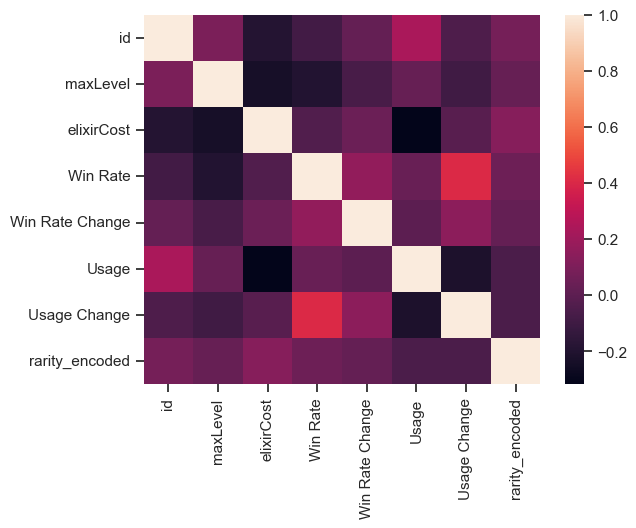

In [72]:
sns.heatmap(data.corr(numeric_only=True))

<Axes: >

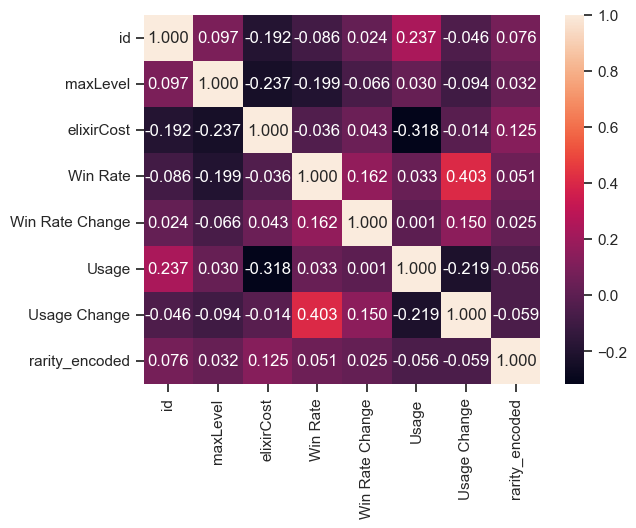

In [73]:
# Вывод значений в ячейках
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt='.3f')

<Axes: >

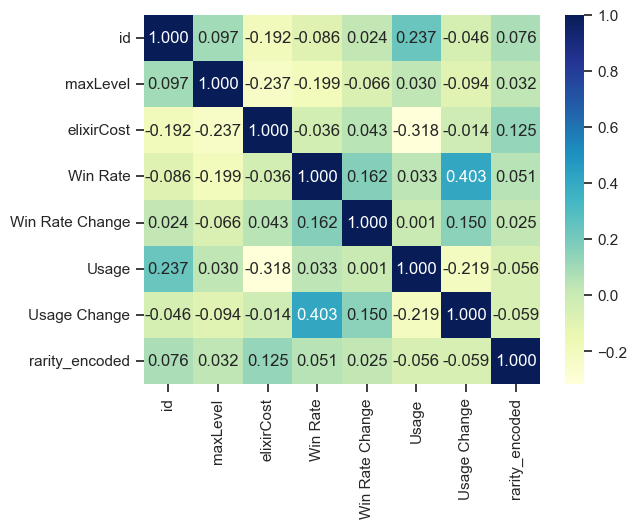

In [74]:
# Изменение цветовой гаммы
sns.heatmap(data.corr(numeric_only=True), cmap='YlGnBu', annot=True, fmt='.3f')

<Axes: >

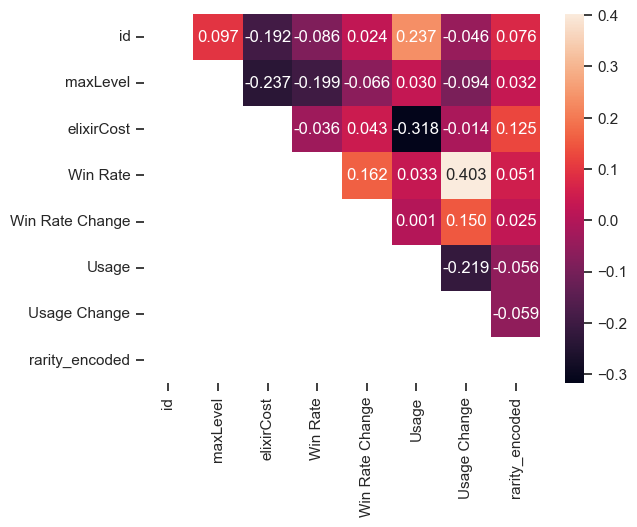

In [76]:
# Треугольный вариант матрицы
mask = np.zeros_like(data.corr(numeric_only=True), dtype=np.bool)
# чтобы оставить нижнюю часть матрицы
# mask[np.triu_indices_from(mask)] = True
# чтобы оставить верхнюю часть матрицы
mask[np.tril_indices_from(mask)] = True
sns.heatmap(data.corr(numeric_only=True), mask=mask, annot=True, fmt='.3f')

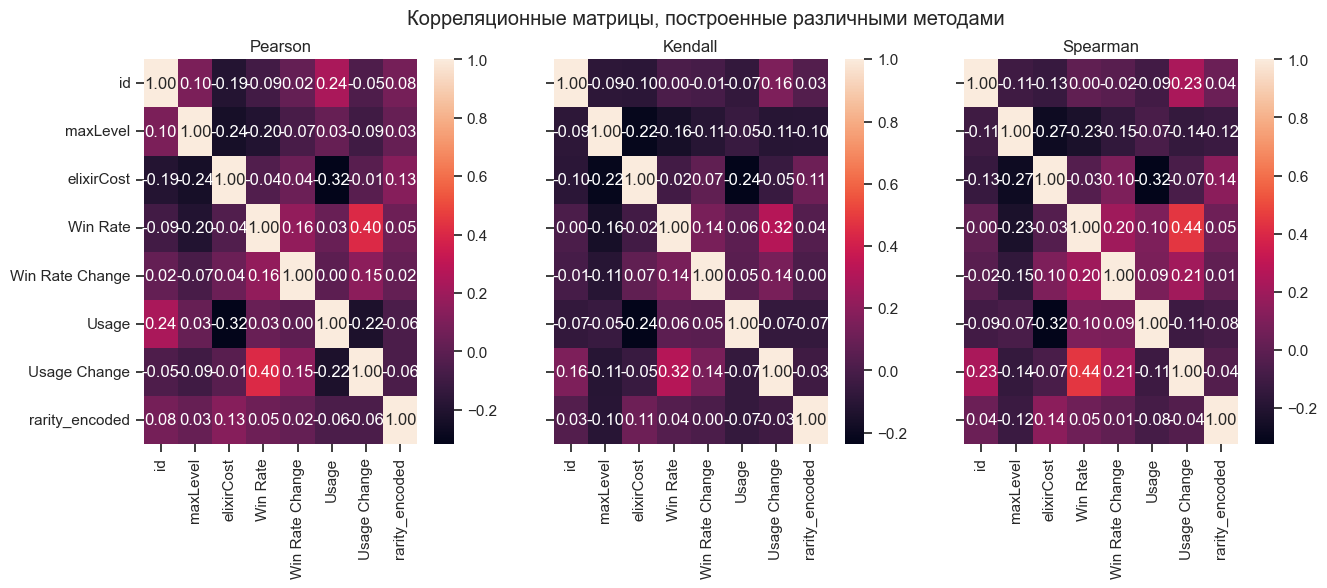

In [77]:
fig, ax = plt.subplots(1, 3, sharex='col', sharey='row', figsize=(15,5))
sns.heatmap(data.corr(method='pearson',numeric_only=True), ax=ax[0], annot=True, fmt='.2f')
sns.heatmap(data.corr(method='kendall',numeric_only=True), ax=ax[1], annot=True, fmt='.2f')
sns.heatmap(data.corr(method='spearman',numeric_only=True), ax=ax[2], annot=True, fmt='.2f')
fig.suptitle('Корреляционные матрицы, построенные различными методами')
ax[0].title.set_text('Pearson')
ax[1].title.set_text('Kendall')
ax[2].title.set_text('Spearman')

### Тепловая карта с указание размера

- Функция plt.subplots создает область окна нужного размера, в которую может выводиться график.
- Параметр figsize=(размер по горизонтали, размер по вертикали).
- По умолчанию размер задается в дюймах, но возможно использование и других единиц измерения - https://matplotlib.org/devdocs/gallery/subplots_axes_and_figures/figure_size_units.html
- Функция sns.heatmap содержит параметр ax=ax, который ссылается на область, созданную plt.subplots, поэтому график выводится в данной области.

<Axes: >

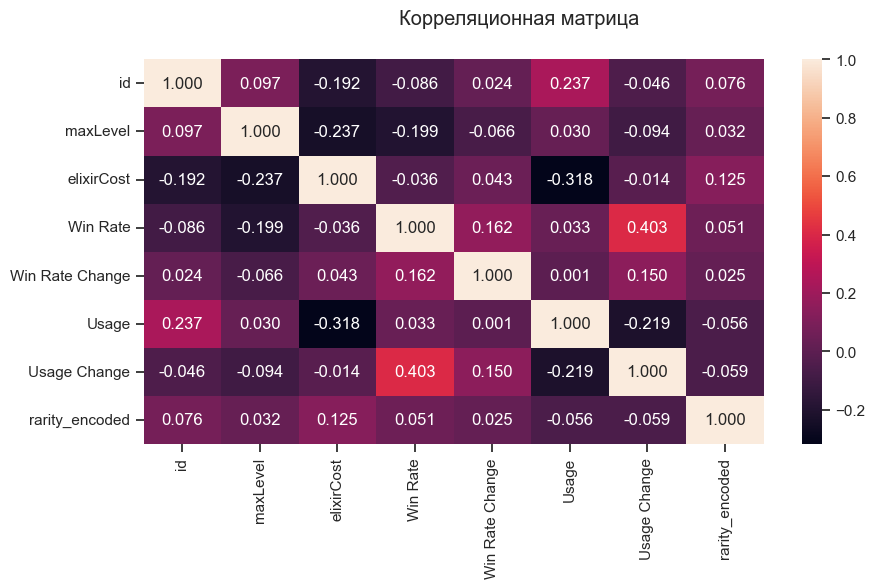

In [78]:
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Корреляционная матрица')
sns.heatmap(data.corr(numeric_only=True), ax=ax, annot=True, fmt='.3f')

Необходимо отметить, что тепловая карта не очень хорошо подходит для определения корреляции нецелевых признаков между собой.

В примере тепловая карта помогает определить значимую корреляцию между признаками Humidity и HumidityRatio, следовательно только один из этих признаков можно включать в модель.

Но в реальной модели могут быть сотни признаков и коррелирующие признаки могут образовывать группы, состояшие более чем из  двух признаков. Увидеть такие группы с помощью тепловой карты сложно.

Для решения задачи предлагается новый вариант визуализации - "Солнечная корреляционная карта" [Solar correlation map](https://github.com/Zapf-Consulting/solar-correlation-map).

К сожалению, данная библиотека пока работает только через файловый интерфейс и не предназначена для встраивания в ноутбук.

Примеры статей с описанием работы библиотеки:
- https://www.oreilly.com/learning/a-new-visualization-to-beautifully-explore-correlations
- https://www.mtab.com/the-puzzle-of-visualizing-correlations/

# Дополнительные ссылки на обучающие ноутбуки

[The Best Tutorial for Beginners (Kaggle)](https://www.kaggle.com/getting-started/71679)